# Hypothesis Testing,P-values,T-tests & Chi-Square

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
df=pd.read_csv("Titanic.csv")

df["Age"]=df["Age"].fillna(df["Age"].median())
print(df.shape)



(891, 12)


 # T-test1: Fare

---------------------------------------------
T-TEST:Fare-Survivors vs Non-Survivors
---------------------------------------------
Survivors Mean Fare: $48.40
Non-Survivors Fare Mean Fare: $22.12

T-Statistic:7.9392
\P-Value:0.000000

 yes 0.0000<0.05
REJECT NO-Significant difference!
Survivors paid significantly higher fares


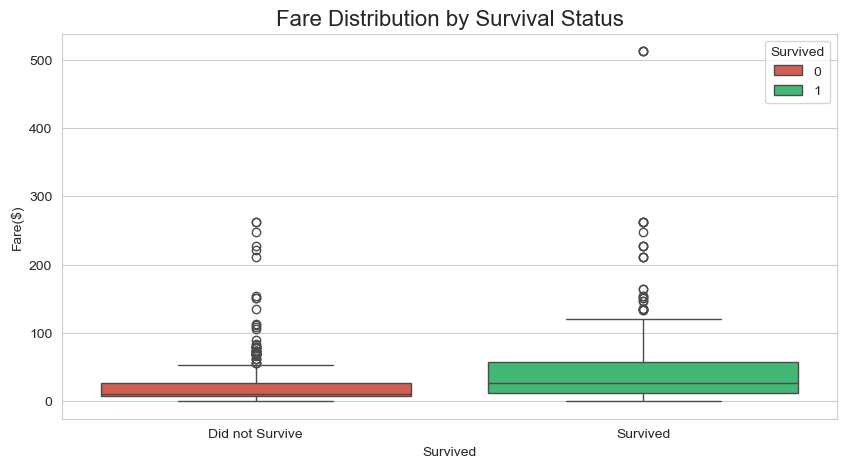

In [2]:

# Did the Survivors pay significantly different fares than the non-survivors?

alpha=0.05

Survivors = df[df["Survived"]==1]["Fare"]
non_Survivors=  df[df["Survived"]==0]["Fare"]

t_stat,p_value=stats.ttest_ind(Survivors,non_Survivors)
print("-"*45)
print("T-TEST:Fare-Survivors vs Non-Survivors")
print("-"*45)

print(f"Survivors Mean Fare: ${Survivors.mean():.2f}")
print(f"Non-Survivors Fare Mean Fare: ${non_Survivors.mean():.2f}")

print(f"\nT-Statistic:{t_stat:.4f}")
print(f"\P-Value:{p_value:.6f}")


# DECESION
if p_value<alpha:
    print(f"\n yes {p_value:.4f}<0.05")
    print("REJECT NO-Significant difference!")
    print("Survivors paid significantly higher fares")
else:
    print(f"\n No p={p_value:.4f}>0.05")
    print("Fail to REJECT NO-No significant Difference")


 # VISUALIZE
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x="Survived",y="Fare",hue="Survived",
            palette=["#e74c3c","#2ecc71"])
plt.xticks([0,1],["Did not Survive","Survived"])
plt.title("Fare Distribution by Survival Status",
         fontsize=16)
plt.ylabel("Fare($)")
plt.show()
           
    
    


# 2.T-test on Age

In [3]:
alpha=0.05

Survivors = df[df["Survived"]==1]["Age"]
non_Survivors=  df[df["Survived"]==0]["Age"]

t_stat,p_value=stats.ttest_ind(Survivors,non_Survivors)
print("-"*45)
print("T-TEST:Age-Survivors vs Non-Survivors")
print("-"*45)

print(f"Survivors Mean Age: ${Survivors.mean():.2f}")
print(f"Non-Survivors Age Mean Fare: ${non_Survivors.mean():.2f}")

print(f"\nT-Statistic:{t_stat:.4f}")
print(f"\P-Value:{p_value:.6f}")


# DECESION
if p_value<0.05:
    print("\n Yes Significant Age difference found")
else:
    print(f"\n No p={p_value:.4f}>0.05")
    print("\n No Significant Age difference found")

---------------------------------------------
T-TEST:Age-Survivors vs Non-Survivors
---------------------------------------------
Survivors Mean Age: $28.29
Non-Survivors Age Mean Fare: $30.03

T-Statistic:-1.9395
\P-Value:0.052761

 No p=0.0528>0.05

 No Significant Age difference found


# Chi-Square1:Survival vs Gender

In [4]:
# Is Survival Related to Gender?

# Hypothesis i)HO:Survival is independent of gender
               # ii)HO:Survival is dependent of gender

# i)Contigency table
contingency=pd.crosstab(df["Sex"],df["Survived"])
print("contigency table:")
print(contingency)
print

# ii)Contingency test
chi2,p_value,dof,expected=stats.chi2_contingency(contingency)

print("-"*45)
print("Chi-Square: Survival vs Gender")
print("-"*45)

print(f"Chi-Square Statistics: {chi2:.4f}")
print(f"p-Value:         {p_value:.10f}")
print(f"Degrees of Freedom: {dof}")

# DECESION
if p_value<0.05:
    print("\n Yes Reject HO")
    print(f"Survival is Significantly related to gender")
else:
    print("\n No Fail to Reject HO")
    print(f" Significant Relationship found")

contigency table:
Survived    0    1
Sex               
female     81  233
male      468  109
---------------------------------------------
Chi-Square: Survival vs Gender
---------------------------------------------
Chi-Square Statistics: 260.7170
p-Value:         0.0000000000
Degrees of Freedom: 1

 Yes Reject HO
Survival is Significantly related to gender


# chi-square2.Survival by Class

In [5]:
# i)Contigency table
contingency2=pd.crosstab(df["Pclass"],df["Survived"])
print("Survival by class:")
print(contingency2)
print()

# ii)Contingency test
chi2,p_value,dof,expected=stats.chi2_contingency(contingency2)

print("-"*45)
print("Chi-Square: Survival vs Gender")
print("-"*45)

print(f"\nChi-Square: {chi2:.4f}")
print(f"p-Value:         {p_value:.10f}")


# DECESION
if p_value<0.05:
    print("\n Yes Passenger class significantly")
    print(f"Survival is Significantly related to gender")
    print("affects survival!")


Survival by class:
Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119

---------------------------------------------
Chi-Square: Survival vs Gender
---------------------------------------------

Chi-Square: 102.8890
p-Value:         0.0000000000

 Yes Passenger class significantly
Survival is Significantly related to gender
affects survival!


In [6]:
# Visualization

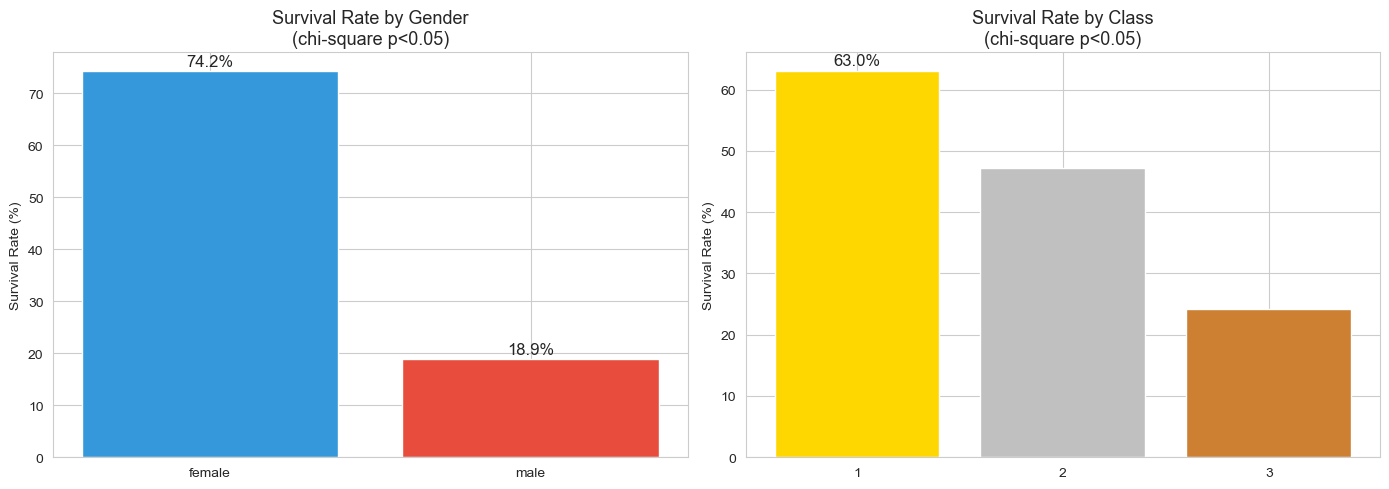

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [7]:
fig, axes= plt.subplots(1,2,figsize=(14,5))

# Survival by Gender
survival_gender=df.groupby("Sex")["Survived"].mean()*100
axes[0].bar(survival_gender.index,
            survival_gender.values,
            color=["#3498db","#e74c3c"])
axes[0].set_title("Survival Rate by Gender\n(chi-square p<0.05)",
                  fontsize=13)
axes[0].set_ylabel("Survival Rate (%)")
for i, v in enumerate (survival_gender.values):
    axes[0].text(i,v+1,f"{v:.1f}%",
                 ha="center",fontsize=12)

    
# Survival by Class
survival_class=df.groupby("Pclass")["Survived"].mean()*100
axes[1].bar(survival_class.index,
            survival_class.values,
            color=["gold","silver","#cd7f32"])
axes[1].set_title("Survival Rate by Class\n(chi-square p<0.05)",
                  fontsize=13)
axes[1].set_ylabel("Survival Rate (%)")
axes[1].set_xticks([1,2,3])
for i, v in zip ([1,2,3],survival_class.values):
    axes[1].text(i,v + 1,f"{v:.1f}%",
                 ha="center",fontsize=12)
    plt.tight_layout()
    plt.show()
                 



    
    
    
    
            
            

In [8]:
df.to_csv("titanic_hypothesis_t&p values.csv" ,index=False)
print('clean file saved!')

clean file saved!
